###PROJET_DE_MACHINE_LEARNING_AVEC_LUCIEN_MSDA1_PLUIE

# **PROBLEMATIQUE**

###Description du projet
OBJECTIFS DU PROJET

bulletin météorologique(weather)
.........................A FAIRE

1. Comprendre la Cible (Target)
Votre objectif est de prédire la variable RainTomorrow.

C'est un problème de classification binaire (Oui ou Non).

Attention au déséquilibre : En Australie, il ne pleut pas tous les jours. Votre modèle risque de prédire "Non" tout le temps et d'avoir une bonne précision (accuracy) tout en étant inutile. Vous devrez surveiller le F1-Score ou l'AUC-ROC.


**A propos du dataset**

Faisons une blef description du dataset

:---------------------------
:---------------------------
:---------------------------
:---------------------------

Les donnees presentees ici proviennent du site du gouvernement de AUSTRALIE
:--------------------------:--------------------:----------------
:--------------------------
:--------------------------
:--------------------------
:--------------------------
:


| Field         | Description                                           | Unit            | Type   |
| :------------ | :---------------------------------------------------- | :-------------- | :----- |
| Date          | La date du relevé YYYY-MM-DD                 | Date            | object |
| Location      | Le nom de la station météorologique                         | Location        | object |
| MinTemp       | Température minimale sur 24 heures                                 | Celsius         | float  |
| MaxTemp       | Température maximale sur 24 heures                                   | Celsius         | float  |
| Rainfall      | La quantité de pluie tombée durant la journée                                   | Millimeters     | float  |
| Evaporation   | Mesure de l'évaporation "en bac" (Class A pan) sur 24 heures jusqu'à 9h                                | Millimeters     | float  |
| Sunshine      | Nombre d'heures de soleil brillant durant la journée                           | hours           | float  |
| WindGustDir   | Direction de la rafale de vent la plus forte sur 24 heures                       | Compass Points  | object |
| WindGustSpeed | Vitesse de la rafale de vent la plus forte (en km/h)                           | Kilometers/Hour | float |
| WindDir9am    | Direction moyenne du vent durant les 10 minutes précédant 9h| Compass Points  | object |
| WindDir3pm    | Direction moyenne du vent durant les 10 minutes précédant 15h| Compass Points  | object |
| WindSpeed9am  | La vitesse du vent (moyenne sur 10 minutes) à 9h      | Kilometers/Hour | float  |
| WindSpeed3pm  | La vitesse du vent (moyenne sur 10 minutes) à 15h      | Kilometers/Hour | float  |
| Humidity9am   | Taux d'humidité relative relevé à 9h (en pourcentage)                                       | Percent         | float  |
| Humidity3pm   | Taux d'humidité relative relevé à 15h (en pourcentage)                                       | Percent         | float  |
| Pressure9am   | Pression atmosphérique au niveau de la mer relevée à 9h (en hectopascals - hPa) | Hectopascal     | float  |
| Pressure3pm   | Pression atmosphérique au niveau de la mer relevée à 15h (en hectopascals - hPa) | Hectopascal     | float  |
| Cloud9am      | Fraction du ciel couverte par les nuages à 9h          | Eights          | float  |
| Cloud3pm      | Fraction du ciel couverte par les nuages à 15h          | Eights          | float  |
| Temp9am       | Temperature à 9am                                    | Celsius         | float  |
| Temp3pm       | Température à 3pm                                  | Celsius         | float  |
| RainToday -> RainYesterday    | Variable binaire. "Yes" si les précipitations ont dépassé 1 mm au cours des dernières 24 heures, sinon "No"               | Yes/No          | object |
| RainTomorrow -> RainToday | Variable à prédire. "Yes" s'il a plu le lendemain, sinon "No"             | Yes/No          | object |


#INSTALLATION ET IMPORTATION DES BIBLITHEQUES NECESSAIRES

In [ ]:
#!pip install numpy
#!pip install pandas
#!pip install matplotlib
#!pip install scikit-learn
#!pip install seaborn
#%matplotlib inline

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

## COMPREHENSION DES DONNEES


# **RECUPERATION DES DONNEES**

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/weatherAUS_rainfall_prediction_dataset_cleaned.csv")

# Affichage des quelques lignes pour voir à quoi ressemble l'ensemble de données
df.head()
# On peut egalement verifier le chargement par dataframe.info()


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2010-04-30,Adelaide,10.8,21.2,0.0,1.8,6.60,ENE,22.0,ENE,...,66.0,48.0,1028.4,1024.7,4.45,4.51,15.7,21.0,No,No
1,2014-07-22,Adelaide,3.7,19.0,0.0,1.4,7.61,N,24.0,N,...,75.0,32.0,1024.2,1021.1,4.45,4.51,9.6,18.5,No,No
2,2014-07-23,Adelaide,9.6,15.8,0.0,2.6,7.61,NE,52.0,NNE,...,35.0,51.0,1017.9,1011.5,4.45,4.51,14.7,15.4,No,Yes
3,2014-07-24,Adelaide,10.1,15.5,16.6,0.8,7.61,NNE,50.0,NW,...,96.0,80.0,1007.4,1008.0,4.45,4.51,11.2,14.0,Yes,Yes
4,2014-07-25,Adelaide,11.2,16.2,1.8,0.6,7.61,NW,30.0,WNW,...,89.0,70.0,1018.4,1019.2,4.45,4.51,13.0,15.3,Yes,Yes


# **PREPARATION DES DONNEES OU DATA WRANGING**

 #### 1. Identification et gestion des valeurs manquants s'ils existent

In [ ]:
missing_data = df.isnull()
missing_data.head(5)
#S'il return true cela veut dire que c'est une valeur manquant
#sinon False

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
#Voyons le nombre de ligne et de colonne
df_shape = df.shape
df_shape

(145460, 23)

In [ ]:
for column in missing_data.columns.values.tolist():
    print(column)
    print (missing_data[column].value_counts())
    print("")

Date
Date
False    145460
Name: count, dtype: int64

Location
Location
False    145460
Name: count, dtype: int64

MinTemp
MinTemp
False    145460
Name: count, dtype: int64

MaxTemp
MaxTemp
False    145460
Name: count, dtype: int64

Rainfall
Rainfall
False    145460
Name: count, dtype: int64

Evaporation
Evaporation
False    145460
Name: count, dtype: int64

Sunshine
Sunshine
False    145460
Name: count, dtype: int64

WindGustDir
WindGustDir
False    145460
Name: count, dtype: int64

WindGustSpeed
WindGustSpeed
False    145460
Name: count, dtype: int64

WindDir9am
WindDir9am
False    145460
Name: count, dtype: int64

WindDir3pm
WindDir3pm
False    145460
Name: count, dtype: int64

WindSpeed9am
WindSpeed9am
False    145460
Name: count, dtype: int64

WindSpeed3pm
WindSpeed3pm
False    145460
Name: count, dtype: int64

Humidity9am
Humidity9am
False    145460
Name: count, dtype: int64

Humidity3pm
Humidity3pm
False    145460
Name: count, dtype: int64

Pressure9am
Pressure9am
False    145460

In [ ]:
df

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2010-04-30,Adelaide,10.8,21.2,0.0,1.80,6.60,ENE,22.0,ENE,...,66.0,48.0,1028.4,1024.7,4.45,4.51,15.7,21.0,No,No
1,2014-07-22,Adelaide,3.7,19.0,0.0,1.40,7.61,N,24.0,N,...,75.0,32.0,1024.2,1021.1,4.45,4.51,9.6,18.5,No,No
2,2014-07-23,Adelaide,9.6,15.8,0.0,2.60,7.61,NE,52.0,NNE,...,35.0,51.0,1017.9,1011.5,4.45,4.51,14.7,15.4,No,Yes
3,2014-07-24,Adelaide,10.1,15.5,16.6,0.80,7.61,NNE,50.0,NW,...,96.0,80.0,1007.4,1008.0,4.45,4.51,11.2,14.0,Yes,Yes
4,2014-07-25,Adelaide,11.2,16.2,1.8,0.60,7.61,NW,30.0,WNW,...,89.0,70.0,1018.4,1019.2,4.45,4.51,13.0,15.3,Yes,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,2012-01-14,Woomera,16.8,31.9,0.0,27.00,7.61,SSE,44.0,SE,...,51.0,17.0,1017.3,1014.2,0.00,4.51,20.2,29.5,No,No
145456,2012-01-15,Woomera,17.0,33.5,0.0,12.40,12.70,SSE,43.0,ESE,...,38.0,12.0,1015.2,1011.8,0.00,0.00,22.2,32.0,No,No
145457,2012-01-16,Woomera,18.9,38.8,0.0,12.00,12.40,N,41.0,ENE,...,10.0,5.0,1012.0,1008.7,0.00,0.00,27.6,37.9,No,No
145458,2012-01-18,Woomera,23.5,38.3,0.0,18.20,13.00,SSE,50.0,SSE,...,54.0,22.0,1013.2,1011.3,1.00,1.00,25.1,35.4,No,No


### **On voit que notre dataset n'a pas de valeurs manquants**

Préparation des données : Sélection et regroupement géographique
L'objectif de cette étape est de spécialiser notre modèle de prédiction météo sur une zone géographique cohérente au lieu de traiter des données disparates provenant de toute l'Australie.
1. Stratégie de regroupement (Clustering)
L'analyse montre que les stations météo de Watsonia et de l'Aéroport de Melbourne sont situées à moins de 20 km du centre de Melbourne.
Hypothèse : Étant donné leur proximité, ces trois localités partagent des systèmes climatiques quasi identiques.
Action : Nous regroupons ces trois points de collecte pour construire un modèle de prédiction localisé.
2. Conservation des micro-variations
Bien que proches, ces lieux peuvent présenter de légères différences (ex: plus de vent à l'aéroport). Pour cette raison, nous conservons la colonne Location comme variable catégorielle. Cela permet au modèle :
De bénéficier d'un volume de données combiné.
D'ajuster ses prédictions en fonction des spécificités de chaque station.
3. Filtrage du Dataset
Le code filtre le DataFrame original pour ne conserver que les lignes correspondant à ces trois lieux.



### Selection de Localisation

In [ ]:
df = df[df.Location.isin(['Melbourne','MelbourneAirport','Watsonia',])]
#df.info()
df['Location'].value_counts()

,count
Location,
Melbourne,3193
MelbourneAirport,3009
Watsonia,3009


Transformer la variable catégorielle en variables quantitatives


In [ ]:
dummy_variable_1=pd.get_dummies(df['Location'], prefix='Location')
dummy_variable_1.head()

,Location_Melbourne,Location_MelbourneAirport,Location_Watsonia
54142,True,False,False
54143,True,False,False
54144,True,False,False
54145,True,False,False
54146,True,False,False


In [ ]:
# fusionner le dataframe "df" et "dummy_variable_1"
#df = pd.concat([df, dummy_variable_1], axis=1) #Ligne a commenter sinon cela
# va concatener a chaque execution

# Supprimer(drop) le colonne d'origine "Location" de "df"
#df.drop("Location", axis = 1, inplace=True)
df.head()

,Date,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Location_Melbourne,Location_MelbourneAirport,Location_Watsonia
54142,2008-08-01,9.7,14.7,0.4,3.8,5.2,WSW,80.0,NW,WSW,...,1001.5,3.0,7.0,11.8,10.9,No,No,True,False,False
54143,2008-08-13,5.5,13.0,1.6,2.0,8.4,WSW,46.0,W,W,...,1025.8,1.0,7.0,7.5,12.6,Yes,No,True,False,False
54144,2008-08-02,8.6,15.3,0.6,3.0,6.0,WSW,46.0,W,WSW,...,1016.1,5.0,6.0,9.8,14.6,No,No,True,False,False
54145,2008-08-03,7.9,14.9,0.0,1.4,5.0,N,52.0,N,N,...,1015.7,2.0,4.0,10.0,13.7,No,No,True,False,False
54146,2008-08-04,9.7,13.6,0.2,2.8,1.0,NNE,54.0,N,NNE,...,1018.1,7.0,7.0,11.1,13.4,No,No,True,False,False


In [ ]:
df.shape

(9211, 25)

Après filtrage, il reste 9211 enregistrements. Ce volume est jugé suffisant pour entraîner un modèle d'apprentissage automatique robuste. Si la précision s'avère insuffisante, nous pourrions :

Élargir la zone à d'autres villes similaires.

Augmenter la fenêtre temporelle des données historiques.

## Point Important A Note

Au lieu de prédire demain, on utilise les données passées pour savoir s'il va pleuvoir aujourd'hui avant de sortir de chez soi. Pour que ce soit plus clair, on renomme les colonnes pour que "la pluie de demain"(RainTomorrow) devienne notre objectif de prédiction pour "aujourd'hui"(RainToday).

In [ ]:
df = df.rename(columns={'RainToday': 'RainYesterday',
                        'RainTomorrow': 'RainToday'
                        })
df.head()

,Date,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainYesterday,RainToday,Location_Melbourne,Location_MelbourneAirport,Location_Watsonia
54142,2008-08-01,9.7,14.7,0.4,3.8,5.2,WSW,80.0,NW,WSW,...,1001.5,3.0,7.0,11.8,10.9,No,No,True,False,False
54143,2008-08-13,5.5,13.0,1.6,2.0,8.4,WSW,46.0,W,W,...,1025.8,1.0,7.0,7.5,12.6,Yes,No,True,False,False
54144,2008-08-02,8.6,15.3,0.6,3.0,6.0,WSW,46.0,W,WSW,...,1016.1,5.0,6.0,9.8,14.6,No,No,True,False,False
54145,2008-08-03,7.9,14.9,0.0,1.4,5.0,N,52.0,N,N,...,1015.7,2.0,4.0,10.0,13.7,No,No,True,False,False
54146,2008-08-04,9.7,13.6,0.2,2.8,1.0,NNE,54.0,N,NNE,...,1018.1,7.0,7.0,11.1,13.4,No,No,True,False,False


### Créer une fonction pour associer les dates aux saisons

In [ ]:
def date_to_season(date):
    month = date.month
    if (month == 12) or (month == 1) or (month == 2):
        return 'Summer' #Summer Été		Décembre, Janvier, Février
    elif (month == 3) or (month == 4) or (month == 5):
        return 'Autumn' #Automn Autumne (ou Fall)	Mars, Avril, Mai
    elif (month == 6) or (month == 7) or (month == 8):
        return 'Winter'	#Winter Hiver	Juin, Juillet, Août
    elif (month == 9) or (month == 10) or (month == 11):
        return 'Spring' #Spring Printemps Septembre, Octobre, Novembre
#A SUPRIME

"""En général, dans un modèle météo (comme celui que tu construis pour Melbourne),
 la date brute (ex: 2024-12-25) est difficile à interpréter pour un algorithme. Transformer cette date en Saison (Été, Automne, Hiver, Printemps)
  est une étape de Feature Engineering cruciale car :

Elle capture la saisonnalité du climat.
Season
Winter    1301
Spring    1115
Autumn    1087
Summer     735
Name: count, dtype: int64
Elle réduit la complexité des données temporelles."""

'En général, dans un modèle météo (comme celui que tu construis pour Melbourne),\n la date brute (ex: 2024-12-25) est difficile à interpréter pour un algorithme. Transformer cette date en Saison (Été, Automne, Hiver, Printemps)\n  est une étape de Feature Engineering cruciale car :\n\nElle capture la saisonnalité du climat.\n\nElle réduit la complexité des données temporelles.'

In [ ]:
# On transforme le texte en objet "Date"
#df['Date'] = pd.to_datetime(df['Date'])

# On crée la saison
#df['Season'] = df['Date'].apply(date_to_season)

#On supprime la date brute qui est devenue inutile
#df=df.drop(columns=['Date'])
df

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,...,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainYesterday,RainToday,Location_Melbourne,Location_MelbourneAirport,Location_Watsonia,Season
54142,9.7,14.7,0.4,3.8,5.2,WSW,80.0,NW,WSW,28.0,...,3.0,7.0,11.8,10.9,No,No,True,False,False,Winter
54143,5.5,13.0,1.6,2.0,8.4,WSW,46.0,W,W,24.0,...,1.0,7.0,7.5,12.6,Yes,No,True,False,False,Winter
54144,8.6,15.3,0.6,3.0,6.0,WSW,46.0,W,WSW,19.0,...,5.0,6.0,9.8,14.6,No,No,True,False,False,Winter
54145,7.9,14.9,0.0,1.4,5.0,N,52.0,N,N,22.0,...,2.0,4.0,10.0,13.7,No,No,True,False,False,Winter
54146,9.7,13.6,0.2,2.8,1.0,NNE,54.0,N,NNE,17.0,...,7.0,7.0,11.1,13.4,No,No,True,False,False,Winter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133388,11.7,16.6,0.4,2.6,0.0,WSW,35.0,WSW,SW,15.0,...,7.0,8.0,13.9,14.8,No,Yes,False,False,True,Spring
133389,9.9,16.7,1.4,1.4,3.9,SSW,37.0,SW,SW,13.0,...,5.0,7.0,14.2,15.2,Yes,Yes,False,False,True,Spring
133390,9.6,17.2,6.2,1.6,2.1,SE,44.0,SE,SSE,13.0,...,7.0,7.0,12.4,15.9,Yes,No,False,False,True,Spring
133391,7.9,13.0,0.0,2.8,3.8,NNW,39.0,N,N,15.0,...,7.0,7.0,9.0,11.7,No,No,False,False,True,Winter


# **ANALYSE EXPLORATOIRE DES DONNEES | AED**

In [ ]:
#Lister les types de données pour chaque colonne
print(df.dtypes)

MinTemp                      float64
MaxTemp                      float64
Rainfall                     float64
Evaporation                  float64
Sunshine                     float64
WindGustDir                   object
WindGustSpeed                float64
WindDir9am                    object
WindDir3pm                    object
WindSpeed9am                 float64
WindSpeed3pm                 float64
Humidity9am                  float64
Humidity3pm                  float64
Pressure9am                  float64
Pressure3pm                  float64
Cloud9am                     float64
Cloud3pm                     float64
Temp9am                      float64
Temp3pm                      float64
RainYesterday                 object
RainToday                     object
Location_Melbourne              bool
Location_MelbourneAirport       bool
Location_Watsonia               bool
Season                        object
dtype: object


Par exemple, nous pouvons calculer la corrélation entre les variables de type 'int64' ou 'float64' en utilisant la méthode 'corr'.

In [ ]:
# Selection des colonnes de types numerique pour voir leur correlation
numeric_df = df.select_dtypes(include=['float64', 'int64'])
numeric_df.corr()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
MinTemp,1.000000,0.679283,0.046432,0.634162,0.066759,0.208189,0.152623,0.137187,-0.365705,-0.166130,-0.433857,-0.408089,0.136789,-0.030855,0.868983,0.635831
MaxTemp,0.679283,1.000000,-0.137612,0.627407,0.499321,0.127678,0.046541,0.073567,-0.451408,-0.629733,-0.230981,-0.317905,-0.228802,-0.308406,0.854121,0.978652
Rainfall,0.046432,-0.137612,1.000000,-0.036940,-0.151039,0.049591,0.012319,0.025795,0.196009,0.204145,-0.186775,-0.113062,0.131196,0.123860,-0.054241,-0.142465
Evaporation,0.634162,0.627407,-0.036940,1.000000,0.290628,0.306129,0.237524,0.210072,-0.531615,-0.373333,-0.356344,-0.342991,-0.071663,-0.120530,0.699492,0.582576
Sunshine,0.066759,0.499321,-0.151039,0.290628,1.000000,-0.002714,-0.033228,0.057010,-0.310573,-0.647837,0.093466,0.036473,-0.558172,-0.631375,0.248911,0.520063
WindGustSpeed,0.208189,0.127678,0.049591,0.306129,-0.002714,1.000000,0.710159,0.751715,-0.449921,-0.157009,-0.485437,-0.480659,-0.020732,0.117529,0.269623,0.087156
WindSpeed9am,0.152623,0.046541,0.012319,0.237524,-0.033228,0.710159,1.000000,0.634708,-0.496799,-0.143989,-0.284597,-0.269703,-0.027704,0.097936,0.205975,0.026363
WindSpeed3pm,0.137187,0.073567,0.025795,0.210072,0.057010,0.751715,0.634708,1.000000,-0.380096,-0.188133,-0.313104,-0.308632,-0.033191,0.042060,0.179840,0.054852
Humidity9am,-0.365705,-0.451408,0.196009,-0.531615,-0.310573,-0.449921,-0.496799,-0.380096,1.000000,0.519057,0.231828,0.256586,0.212285,0.101358,-0.588776,-0.419535
Humidity3pm,-0.166130,-0.629733,0.204145,-0.373333,-0.647837,-0.157009,-0.143989,-0.188133,0.519057,1.000000,-0.022305,0.072212,0.396170,0.412038,-0.384150,-0.690296


Nous constatons que MaxTemp et Temp3pm ($0.978652$) : qu'ils ont une corrélation quasi-parfaite comme on le dit ainsi que Temp9am et MinTemp sont des variables fortement correlées ($0.868983$). En Australie particulierement pour les villes comme Melbourne, MelbourneAirport et Watsonia, la température maximale de la journée survient souvent autour de 15h (Temp3pm). Mathématiquement, ces deux colonnes sont presque des "doublons". Il y'en a d'autres multicolinéarité.
Mais on sait que les algorithmes de boosting sont généralement moins sensibles à la multicolinéarité, surtout lorsqu’ils sont basés sur des arbres (comme Gradient Boosting, XGBoost, LightGBM)

In [ ]:
# Liste des paires critiques à examiner pour la redondance
#df[['MaxTemp', 'Temp3pm', 'MinTemp', 'Temp9am']].corr()

# Liste des paires de pression et humidité
#[['Pressure9am', 'Pressure3pm', 'Humidity9am', 'Humidity3pm']].corr()

# Liste des indicateurs de ciel et pluie (pour voir les relations inverses)
df[['Sunshine', 'Evaporation', 'Cloud9am', 'Cloud3pm', 'Rainfall']].corr()

# Liste des vitesses de vent
#df[['WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm']].corr()


,Sunshine,Evaporation,Cloud9am,Cloud3pm,Rainfall
Sunshine,1.000000,0.290628,-0.558172,-0.631375,-0.151039
Evaporation,0.290628,1.000000,-0.071663,-0.120530,-0.036940
Cloud9am,-0.558172,-0.071663,1.000000,0.395948,0.131196
Cloud3pm,-0.631375,-0.120530,0.395948,1.000000,0.123860
Rainfall,-0.151039,-0.036940,0.131196,0.123860,1.000000


#### Pour les variables categorielles

Les variables catégorielles peuvent être de type "object" ou "int64". Une bonne manière de visualiser les variables catégorielles est d'utiliser des boîtes à moustaches (boxplots).

<Axes: xlabel='Temp9am', ylabel='RainToday'>

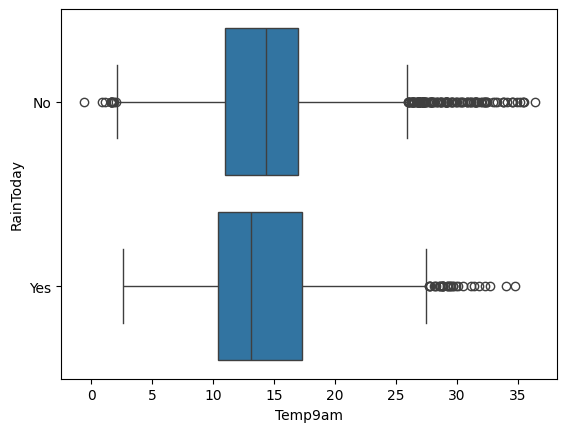

In [ ]:
sns.boxplot(x="Temp9am", y="RainToday", data=df)

In [ ]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,9211.000000,9211.000000,9211.000000,9211.000000,9211.000000,9211.000000,9211.000000,9211.000000,9211.000000,9211.000000,9211.000000,9211.000000,9211.000000,9211.000000,9211.000000,9211.000000
mean,10.674295,20.848075,1.771326,4.647229,6.383078,43.559401,16.491712,20.160749,71.980189,52.349565,1017.912518,1016.014969,5.172761,5.189239,14.300917,19.332051
std,4.385920,6.349473,4.856883,3.330154,3.914030,15.686097,11.184968,9.654700,16.323722,17.168512,7.525687,7.356754,2.384393,2.210973,4.901150,6.131560
min,-2.100000,8.400000,0.000000,0.000000,0.000000,9.000000,0.000000,0.000000,11.000000,6.000000,988.900000,988.200000,0.000000,0.000000,-0.600000,6.200000
25%,7.600000,15.800000,0.000000,2.200000,3.000000,31.000000,9.000000,13.000000,62.000000,42.000000,1013.200000,1011.400000,4.000000,4.000000,10.800000,14.500000
50%,10.600000,19.900000,0.000000,4.000000,6.500000,41.000000,13.000000,19.000000,71.000000,51.540000,1017.650000,1015.800000,6.000000,6.000000,14.000000,18.500000
75%,13.500000,24.300000,2.000000,6.400000,9.600000,54.000000,22.000000,26.000000,83.000000,62.000000,1022.900000,1020.900000,7.000000,7.000000,16.990000,22.600000
max,30.500000,46.800000,87.400000,23.800000,13.900000,122.000000,67.000000,76.000000,100.000000,100.000000,1039.300000,1036.000000,8.000000,8.000000,36.400000,46.100000


In [ ]:
#donne moi les 5 derniers jour ou l evaporation est max et y a pluie
#df[df['Evaporation']==df['Evaporation'].max()].tail()
#tous les jours ou y a pluie
#df[df['Rainfall']>0]
# Filtrer les jours où il y'a vraiment pluie et compter par saison
pluie_par_saison = df[df['RainToday'] == "Yes"]['Season'].value_counts()
print(pluie_par_saison)

Season
Winter    634
Spring    582
Autumn    480
Summer    331
Name: count, dtype: int64


`Analyse:On voit que (Décembre, Janvier, Février) summer ou l'ete est la saison la pluie seche les pluie sont un peu moins important que les autres saison a savoir Autumn, Spring et Winter ainsi donnee avec suivant leur ordre d'important sur la pluie`

In [ ]:
# Probabilité qu'il pleuve demain s'il pleut aujourd'hui, par saison
print(df[df['RainYesterday'] == "Yes"].groupby('Season')['RainToday'].value_counts(normalize=True))

Season  RainToday
Autumn  No           0.620332
        Yes          0.379668
Spring  No           0.605489
        Yes          0.394511
Summer  No           0.712538
        Yes          0.287462
Winter  No           0.618898
        Yes          0.381102
Name: proportion, dtype: float64


In [ ]:
# 1. Delta de Pression
df['Pressure_Delta'] = df['Pressure9am'] - df['Pressure3pm']
print(df.groupby('RainToday')['Pressure_Delta'].mean())

# 2. Corrélation RainToday / RainTomorrow
print(pd.crosstab(df['RainYesterday'], df['RainToday'], normalize='index'))

# 3. Vent dominant les jours de pluie
print(df[df['Rainfall'] > 0]['WindGustDir'].value_counts().head(5))

RainToday
No     1.957187
Yes    1.686182
Name: Pressure_Delta, dtype: float64
RainToday            No       Yes
RainYesterday                    
No             0.822105  0.177895
Yes            0.630488  0.369512
WindGustDir
N      812
S      508
SW     493
SSW    450
WSW    428
Name: count, dtype: int64


## Définir les DataFrames de caractéristiques (features) et de cible (target).

In [ ]:
# X contient toutes les variables explicatives (on retire la cible)
X = df.drop(columns='RainToday', axis=1)

# y contient uniquement la variable que l'on veut prédire
y = df['RainToday']

In [ ]:
#X.shape
y.shape

(9211,)

À quel point les classes sont-elles équilibrées ?

In [ ]:
# Si tu travailles sur le dataframe complet :
df['RainToday'].value_counts()

# Avec le y
#y.value_counts()

,count
RainToday,
No,7184
Yes,2027


Il ne pleut pas la majorité du temps ; les jours sans pluie sont environ 3,5 fois plus nombreux que les jours de pluie.
Il pleut environ 22% du temps (soit environ 1 jour sur 4 ou 5).

Ceci veut dire que le jeu de données est déséquilibré (imbalanced), car la classe "No" est largement dominante par rapport à la classe "Yes".

# **MODELISATION**

### Division du dataset pour l'entrainement et le test avec echantillonage stratifie

On garde 20% des données pour tester le modèle et 80% pour l'entraîner.

La stratification garantit que nous auras la même proportion de "Yes" et de "No" dans le jeu d'entraînement et dans le jeu de test.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

Définir les transformateurs de prétraitement pour les caractéristiques numériques et catégorielles.

In [ ]:
numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

vérifier les colonnes

In [ ]:
print(f"Variables numériques : {numeric_features}")
print(f"Variables catégorielles : {categorical_features}")

Variables numériques : ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']
Variables catégorielles : ['Date', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainYesterday']


Les pipelines offrent une flexibilite du code et empeche les fuites de donnees.

Définir des transformateurs séparés pour les deux types de caractéristiques et les combiner en un seul transformateur de prétraitement unique.

Egalement, les pipelines de données simplifient les étapes de traitement des données. Nous utilisons le module Pipeline pour créer un pipeline. Nous utilisons également StandardScaler comme une étape dans notre pipeline.

In [ ]:
# Scale the numeric features
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])

# One-hot encode the categoricals
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])

Combinaison des transformateurs en un seul transformateur de colonnes de prétraitement unique.

C'est créer une seule machine qui trie et nettoie automatiquement tes "chiffres" et tes "mots" en un seul passage pour que ton modèle reçoive des données parfaite

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

Les forêts aléatoires sont une méthode de bagging(boostrap aggregating) qui entraîne plusieurs arbres de décision sur des ensembles de données bootstrapés. Ces arbres n'ont pas besoin d'être très profonds. L'accent devrait plutôt être mis sur la réduction des biais de prédiction.

In [ ]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

Définir le Grid Search pour la validation croisée est l'étape qui permet de passer d'un modèle "standard" à un modèle optimisé spécifiquement pour tes données

In [ ]:
param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

On a assemblé le prétraitement et le modèle Random Forest dans un Pipeline pour garantir une transformation des données cohérente et éviter toute fuite d'information (data leakage).

Nous avons ensuite appliqué une Grid Search avec Validation Croisée ($k=5$) pour tester automatiquement différentes combinaisons d'hyperparamètres (nombre d'arbres, profondeur) sur plusieurs échantillons de données.

Cette approche rigoureuse permet de sélectionner le meilleur modèle possible, maximisant ainsi la précision des prédictions de pluie.

Sélectionnez une méthode de validation croisée, en garantissant la stratification de la cible durant la validation

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True)#Conserver la proportion des classes dans chaque sous-ensemble

Instancions et entraînons GridSearchCV au pipeline.

In [ ]:
grid_search = GridSearchCV(pipeline, param_grid, cv=cv, scoring='accuracy', verbose=2)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   2.5s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   2.8s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   3.4s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   2.3s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   2.4s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   4.8s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   6.1s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['MinTemp',
                                                                          'MaxTemp',
                                                                          'Rainfall',
                                                                          'Evaporation',
                                                                          'Sunshine',
                                                                          'WindGustSpeed',
                                                                          'WindSpeed9am',
                                                                          'WindSpeed3pm',
                                                                          'Humidity9am',
                                                                          'Humidity3pm',
                                                                          'Pressure9am',
                                                                          'Pr...
                                                                        ('cat',
                                                                         Pipeline(steps=[('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Date',
                                                                          'WindGustDir',
                                                                          'WindDir9am',
                                                                          'WindDir3pm',
                                                                          'RainYesterday'])])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             param_grid={'classifier__max_depth': [None, 10, 20],
                         'classifier__min_samples_split': [2, 5],
                         'classifier__n_estimators': [50, 100]},
             scoring='accuracy', verbose=2)

Affiche les meilleurs paramètres et le meilleur score de validation croisée.

In [ ]:
print("\nMeilleurs parametres trouves: ", grid_search.best_params_)
print("meilleur score de validation croisée: {:.2f}".format(grid_search.best_score_))


Meilleurs parametres trouves:  {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
meilleur score de validation croisée: 0.85


# **EVALUATION DU MODELE**

Voyons le score estimé de notre modèle.

In [ ]:
test_score = grid_search.score(X_test, y_test)
print("Score de test: {:.2f}".format(test_score))

Score de test: 0.85


Nous avons donc un classifieur raisonnablement précis, dont on attend qu'il prédise correctement environ 84 % du temps s'il va pleuvoir aujourd'hui dans la région de Melbourne. Mais attention ici. Regardons les résultats de plus près. Le meilleur modèle est stocké à l'intérieur de l'objet gridsearch

Obtenez les prédictions du modèle à partir de l'estimateur de la recherche par grille sur les données non vues.

In [ ]:
y_pred = grid_search.predict(X_test)

Affiche le rapport de classification

In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

          No       0.86      0.97      0.91      1437
         Yes       0.79      0.44      0.56       406

    accuracy                           0.85      1843
   macro avg       0.83      0.70      0.74      1843
weighted avg       0.84      0.85      0.83      1843



Le support (le nombre d'exemples) pour la classe "Non" est 3,5 fois supérieur à celui de la classe "Oui". Cela confirme que nos données sont fortement déséquilibrées, ce qui explique pourquoi l'accuracy de 84 % peut être trompeuse.

___
____
__
_

Affiche la matrice de confusion.

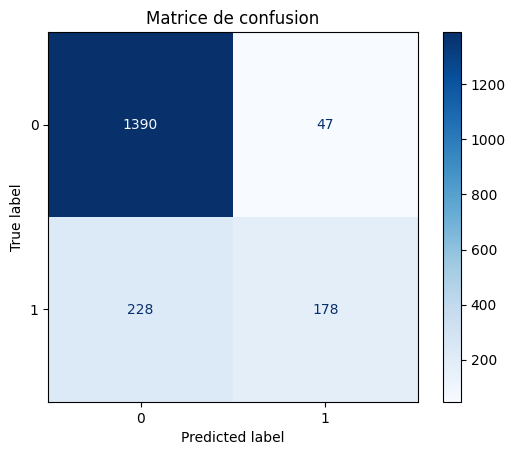

In [ ]:
matrice_de_conf = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=matrice_de_conf)
disp.plot(cmap='Blues')
plt.title('Matrice de confusion')
plt.show()

In [ ]:
# Combine numeric and categorical feature names
feature_names = numeric_features + list(grid_search.best_estimator_['preprocessor']
                                        .named_transformers_['cat']
                                        .named_steps['onehot']
                                        .get_feature_names_out(categorical_features))

feature_importances = grid_search.best_estimator_['classifier'].feature_importances_

importance_df = pd.DataFrame({'Feature': feature_names,
                              'Importance': feature_importances
                             }).sort_values(by='Importance', ascending=False)

N = 20  # Change this number to display more or fewer features
top_features = importance_df.head(N)

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'], color='skyblue')
plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature on top
plt.title(f'Top {N} Most Important Features in predicting whether it will rain today')
plt.xlabel('Importance Score')
plt.show()

ValueError: All arrays must be of the same length

In [ ]:
# 1. Extraire les scores d'importance (valeurs brutes)
importances = grid_search.best_estimator_['classifier'].feature_importances_

# 2. Récupérer les noms des colonnes après transformation
# Pour les colonnes numériques (pas de changement de nom)
num_features = grid_search.best_estimator_['preprocessor'].transformers_[0][2]

# Pour les colonnes catégorielles (noms modifiés par le OneHotEncoder)
cat_features = grid_search.best_estimator_['preprocessor'].transformers_[1][1].get_feature_names_out()

# 3. Combiner tous les noms dans le bon ordre
all_feature_names = list(num_features) + list(cat_features)

# 4. Créer un DataFrame pour visualiser le tout proprement
feature_importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feature_importance_df.head(24))

                feature  importance
9           Humidity3pm    0.080384
11          Pressure3pm    0.064589
10          Pressure9am    0.060831
4              Sunshine    0.050401
15              Temp3pm    0.044763
5         WindGustSpeed    0.039366
1               MaxTemp    0.037803
14              Temp9am    0.034927
13             Cloud3pm    0.033940
8           Humidity9am    0.032976
0               MinTemp    0.032437
3           Evaporation    0.029887
7          WindSpeed3pm    0.027718
6          WindSpeed9am    0.027036
2              Rainfall    0.025791
12             Cloud9am    0.022284
3190   RainYesterday_No    0.009477
3191  RainYesterday_Yes    0.008885
3161       WindDir9am_N    0.006357
3145      WindGustDir_N    0.006343
3177       WindDir3pm_N    0.005549
3182       WindDir3pm_S    0.004831
3154     WindGustDir_SW    0.004764
3155      WindGustDir_W    0.004068
